In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Lasso,Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("train (1).csv")

In [5]:
df.head(5)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [7]:
df.shape

(913000, 4)

In [8]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [14]:
parts=df["date"].str.split("-",n=3,expand=True)
df["year"]=parts[0].astype('int')
df["month"]=parts[1].astype('int')
df["day"]=parts[2].astype('int')

df.head()

,date,store,item,sales,Year,Month,day,year,month
0,2013-01-01,1,1,13,2013,1,1,2013,1
1,2013-01-02,1,1,11,2013,1,2,2013,1
2,2013-01-03,1,1,14,2013,1,3,2013,1
3,2013-01-04,1,1,13,2013,1,4,2013,1
4,2013-01-05,1,1,10,2013,1,5,2013,1


In [15]:
from datetime import datetime
def weekend_or_weekday(year,month,day):
    d=datetime(year,month,day)
    return 1 if d.weekday()>4 else 0
df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)


In [16]:
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))
df.head()

,date,store,item,sales,Year,Month,day,year,month,weekend,m1,m2
0,2013-01-01,1,1,13,2013,1,1,2013,1,0,0.5,0.866025
1,2013-01-02,1,1,11,2013,1,2,2013,1,0,0.5,0.866025
2,2013-01-03,1,1,14,2013,1,3,2013,1,0,0.5,0.866025
3,2013-01-04,1,1,13,2013,1,4,2013,1,0,0.5,0.866025
4,2013-01-05,1,1,10,2013,1,5,2013,1,1,0.5,0.866025


In [19]:
df["date"] = pd.to_datetime(df["date"])

In [20]:
df["WeekDay"]=df["date"].dt.weekday

In [21]:
df.head(5)

,date,store,item,sales,Year,Month,day,year,month,weekend,m1,m2,WeekDay
0,2013-01-01,1,1,13,2013,1,1,2013,1,0,0.5,0.866025,1
1,2013-01-02,1,1,11,2013,1,2,2013,1,0,0.5,0.866025,2
2,2013-01-03,1,1,14,2013,1,3,2013,1,0,0.5,0.866025,3
3,2013-01-04,1,1,13,2013,1,4,2013,1,0,0.5,0.866025,4
4,2013-01-05,1,1,10,2013,1,5,2013,1,1,0.5,0.866025,5


In [22]:
df.drop("date",axis=1,inplace=True)

In [31]:
df[["store","item"]].value_counts()

store  item
1      1       1826
7      30      1826
       43      1826
       42      1826
       41      1826
               ... 
4      12      1826
       11      1826
       10      1826
       9       1826
10     50      1826
Name: count, Length: 500, dtype: int64

In [41]:
df.head(5)

,store,item,sales,Year,Month,day,year,month,weekend,m1,m2,WeekDay
0,1,1,13,2013,1,1,2013,1,0,0.5,0.866025,1
1,1,1,11,2013,1,2,2013,1,0,0.5,0.866025,2
2,1,1,14,2013,1,3,2013,1,0,0.5,0.866025,3
3,1,1,13,2013,1,4,2013,1,0,0.5,0.866025,4
4,1,1,10,2013,1,5,2013,1,1,0.5,0.866025,5


In [45]:
features=["store","month","year","weekend","WeekDay"]

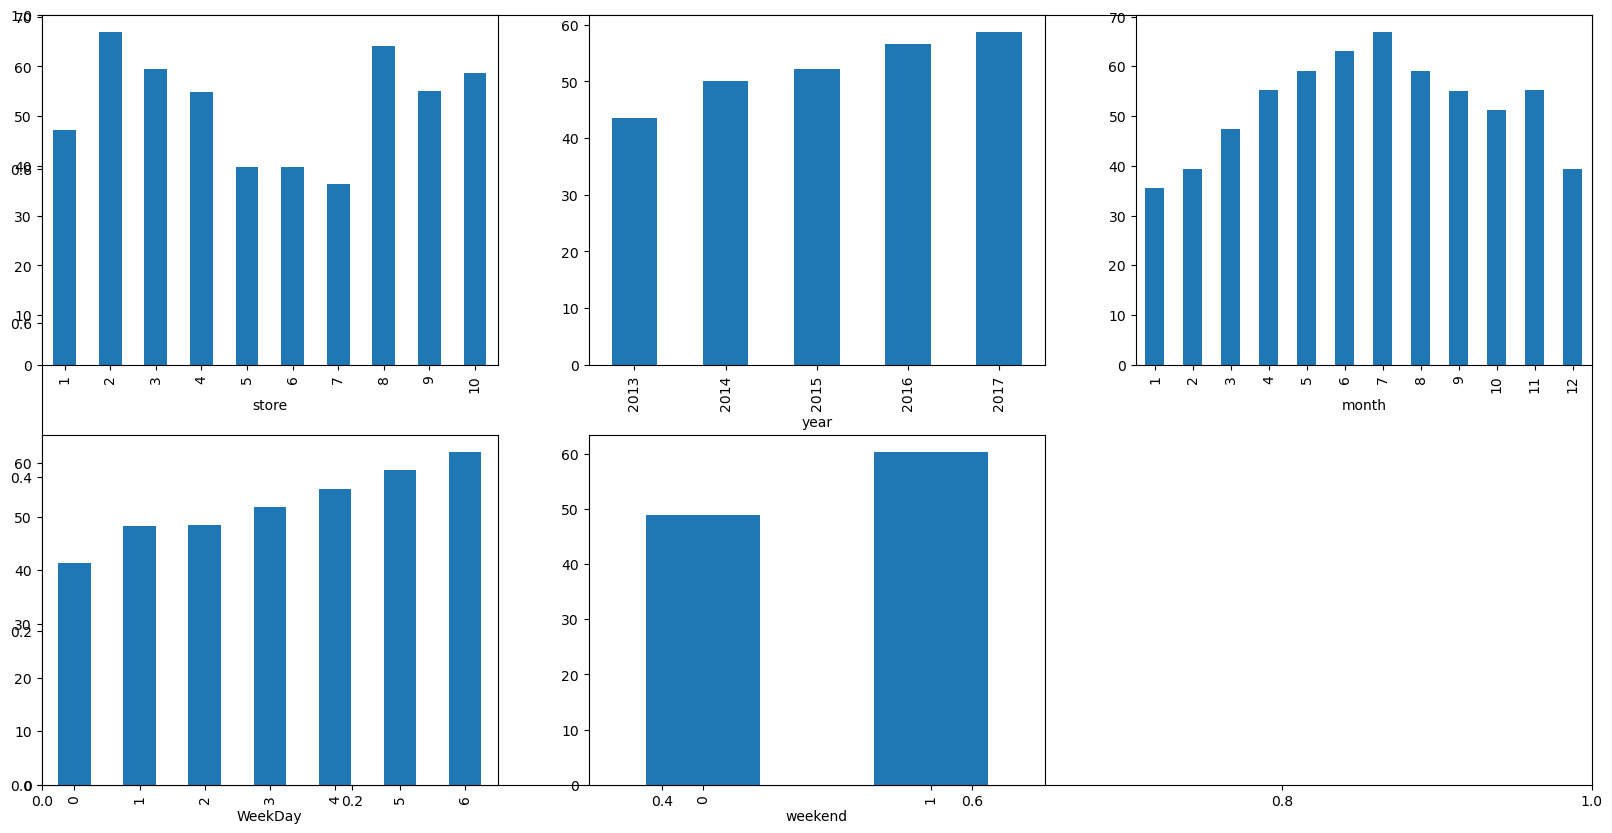

In [47]:
df['weekend'] = df['WeekDay'].apply(lambda x: 1 if x >= 5 else 0)
features = ['store', 'year', 'month', 'WeekDay', 'weekend']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['sales'].plot.bar()
plt.show()

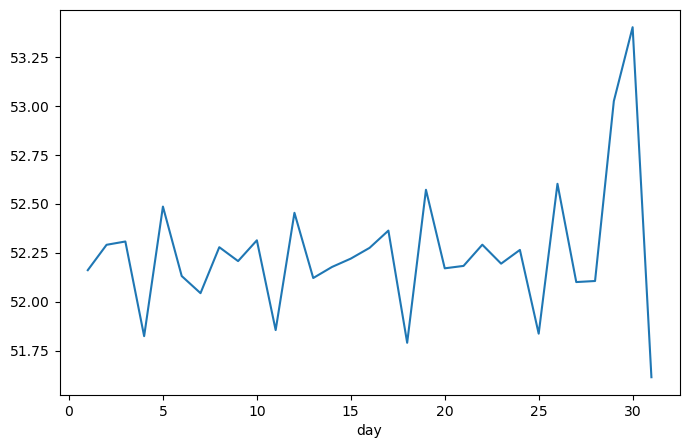

In [49]:
plt.figure(figsize=(8,5))
df.groupby('day').mean()['sales'].plot()
plt.show()

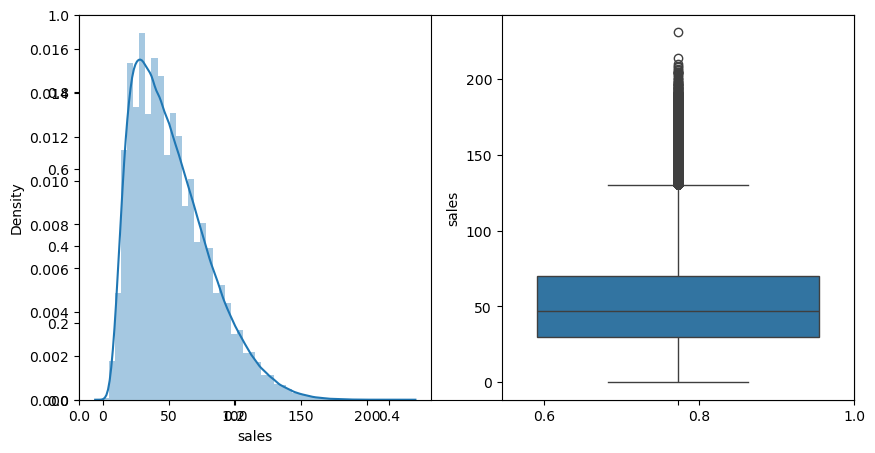

In [56]:
plt.subplots(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.distplot(df['sales'])

plt.subplot(1, 2, 2)
sns.boxplot(df['sales'])
plt.show()

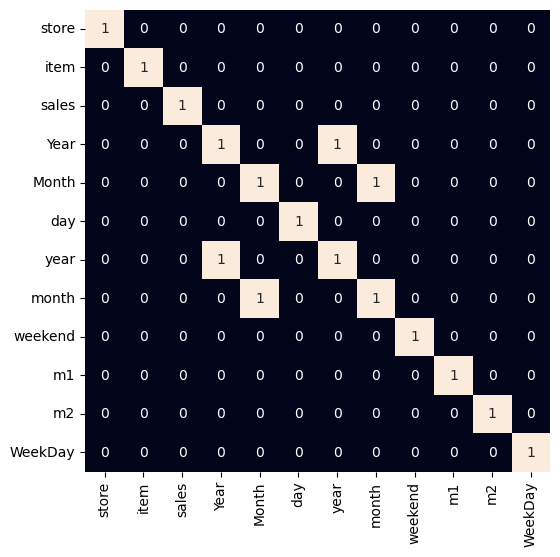

In [57]:
plt.figure(figsize=(6, 6))
sns.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [59]:
X = df.drop(['sales', 'year'], axis=1)
Y = df['sales'].values


X_train, X_test, Y_train, Y_test = train_test_split(X,Y,
                                                  test_size = 0.05,
                                                  random_state=22)
X_train.shape, X_test.shape

((867350, 10), (45650, 10))

In [61]:
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
from sklearn.metrics import mean_absolute_error as mae

In [73]:
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()]

for i in range(4):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    test_preds = models[i].predict(X_test)
    print('Validation Error : ', mae(Y_test, test_preds))
    print()


LinearRegression() : 
Training Error :  21.042501092041988
Validation Error :  10554.351195817124

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...) : 
Training Error :  5.900693416595459
Validation Error :  42.39634323120117

Lasso() : 
Training Error :  21.143170390996715
Validation Error :  8560.206704867805

Ridge() : 
Training Error :  21.042501072423896

In [76]:
y_pred=XGB.predict(X_test)